# **Phase 3 — Analyse, Visualise & Report**

 ***Exploratory Data Analysis + Math Basic***

 We will create charts, compute statistics, and write up what
you found.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
FEATURES_PATH = 'ames_features.csv'
df = pd.read_csv(FEATURES_PATH)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Loaded: 2,929 rows x 113 columns


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,...,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,price_per_sqft,bath_per_bed,qual_x_area,Lot Area log1p,House Age Group
0,1,526301100,20,141.0,2.743896,Pave,IR1,Lvl,AllPub,Corner,...,False,False,False,False,False,129.830918,0.333333,9936,10.366309,Old
1,2,526350040,20,80.0,0.187048,Pave,Reg,Lvl,AllPub,Inside,...,False,False,False,False,False,117.187500,0.500000,4480,9.360741,Old
2,3,526351010,20,81.0,0.522707,Pave,IR1,Lvl,AllPub,Corner,...,False,False,False,False,False,129.420617,0.500000,7974,9.565775,Old
3,4,526353030,20,93.0,0.128418,Pave,Reg,Lvl,AllPub,Corner,...,False,False,False,False,False,115.639810,0.833333,14770,9.320181,Old
4,5,527105010,60,74.0,0.467250,Pave,IR1,Lvl,AllPub,Inside,...,False,False,False,False,False,116.574586,0.833333,8145,9.534668,Recent


## Task 1 — Histograms / KDE

---
# **Histograms / KDE: plot distributions of at least 3 numerical features**

---
**Insight:**
- **SalePrice** is right-skewed — most houses sell between $100k–$200k,
  but a long tail extends toward $450k. This confirms our log-transform decision in Phase 2.
- **Gr Liv Area** appears approximately normal after StandardScaler (centered around 0),
  with a slight right tail from large houses.
- **Overall Quality** is roughly symmetric and centered around 5–6,
  suggesting most houses are average-to-good quality with few extremes.






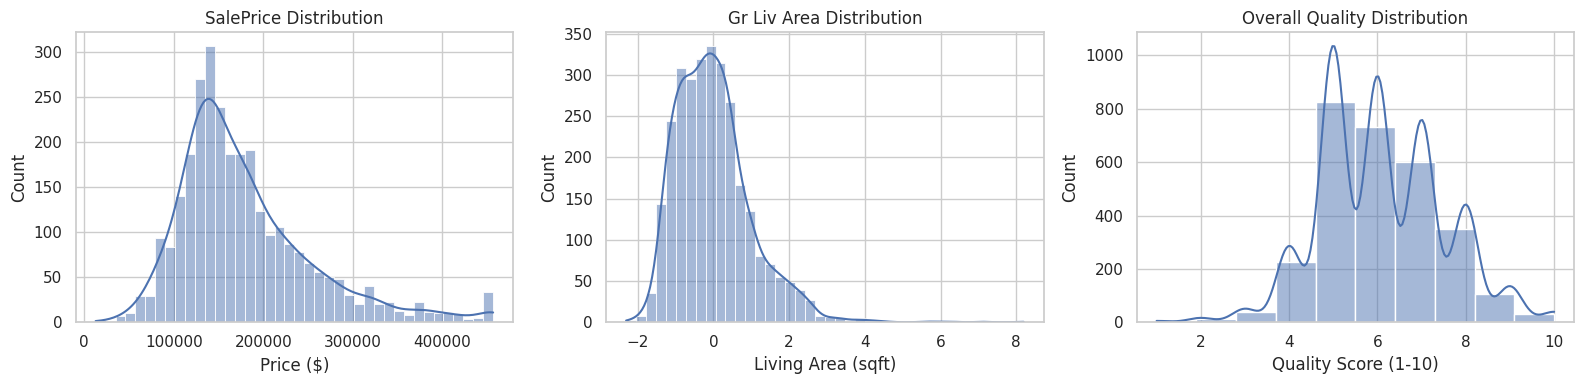

In [2]:
# Source: Week 6, Day 26 — Histograms & KDE
# Source: Week 7, Day 31 — Seaborn histplot with KDE
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['SalePrice'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('SalePrice Distribution')
axes[0].set_xlabel('Price ($)')
#------
sns.histplot(df['Gr Liv Area'], bins=40, kde=True, ax=axes[1])
axes[1].set_title('Gr Liv Area Distribution')
axes[1].set_xlabel('Living Area (sqft)')
#------
sns.histplot(df['Overall Qual'], bins=10, kde=True, ax=axes[2])
axes[2].set_title('Overall Quality Distribution')
axes[2].set_xlabel('Quality Score (1-10)')
#------

plt.tight_layout()
plt.show()

# **Task 2 (Boxplots):**

---
# **Compare the target across at least 2 categories**

---
**Insight:** SalePrice rises consistently with Overall Quality, median price
for quality 10 is nearly 10x that of quality 1. Newer houses command
significantly higher prices, with New and Recent groups showing medians
above $200k versus $120k for Very Old houses.


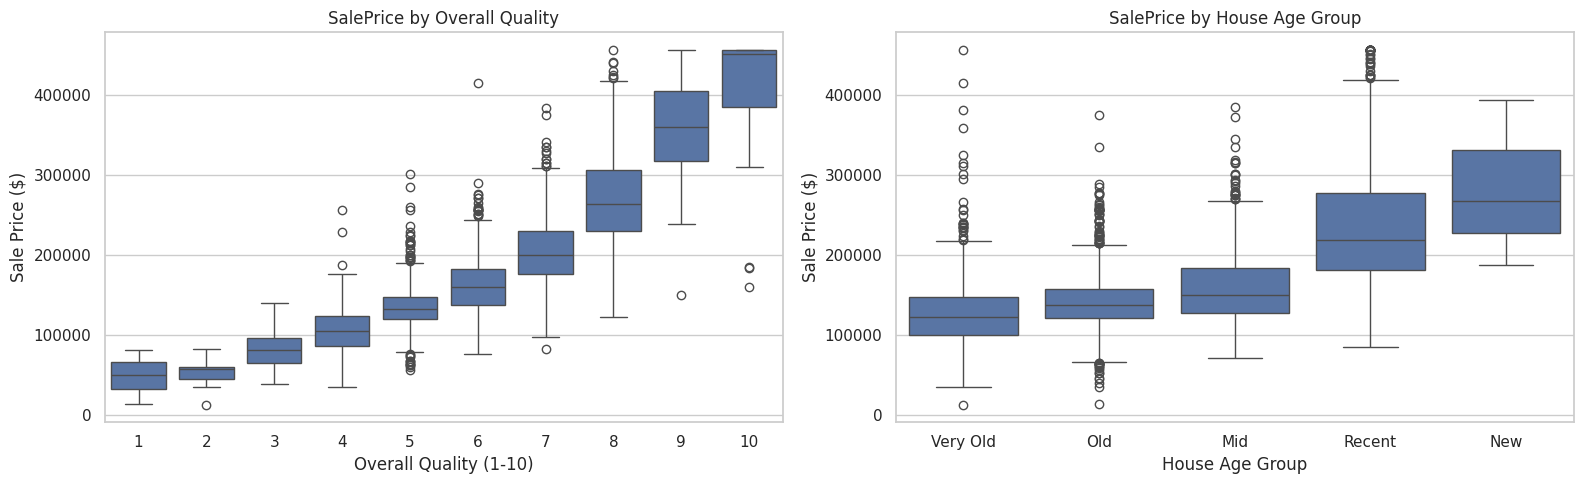

In [3]:
#
# Source: Week 6, Day 27 — Boxplots
# Source: Week 7, Day 31 — Seaborn boxplot by category
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Boxplot 1: SalePrice by Overall Quality --
sns.boxplot(data=df, x='Overall Qual', y='SalePrice', ax=axes[0])
axes[0].set_title('SalePrice by Overall Quality')
axes[0].set_xlabel('Overall Quality (1-10)')
axes[0].set_ylabel('Sale Price ($)')
# Boxplot 2: SalePrice by House Age Group --
sns.boxplot(data=df, x='House Age Group', y='SalePrice',  order=['Very Old', 'Old', 'Mid', 'Recent', 'New'], ax=axes[1])
axes[1].set_title('SalePrice by House Age Group')
axes[1].set_xlabel('House Age Group')
axes[1].set_ylabel('Sale Price ($)')

plt.tight_layout()
plt.show()

# **Task 3 (Heatmap):**

---
# **We show the top 10 features most correlated with the target**

---
**Insight:** qual_x_area has the strongest correlation with SalePrice (0.84),
confirming that our engineered interaction feature captures more signal than
either quality or area alone. Garage Cars and Garage Area are highly correlated
with each other (0.89), suggesting one could be dropped.


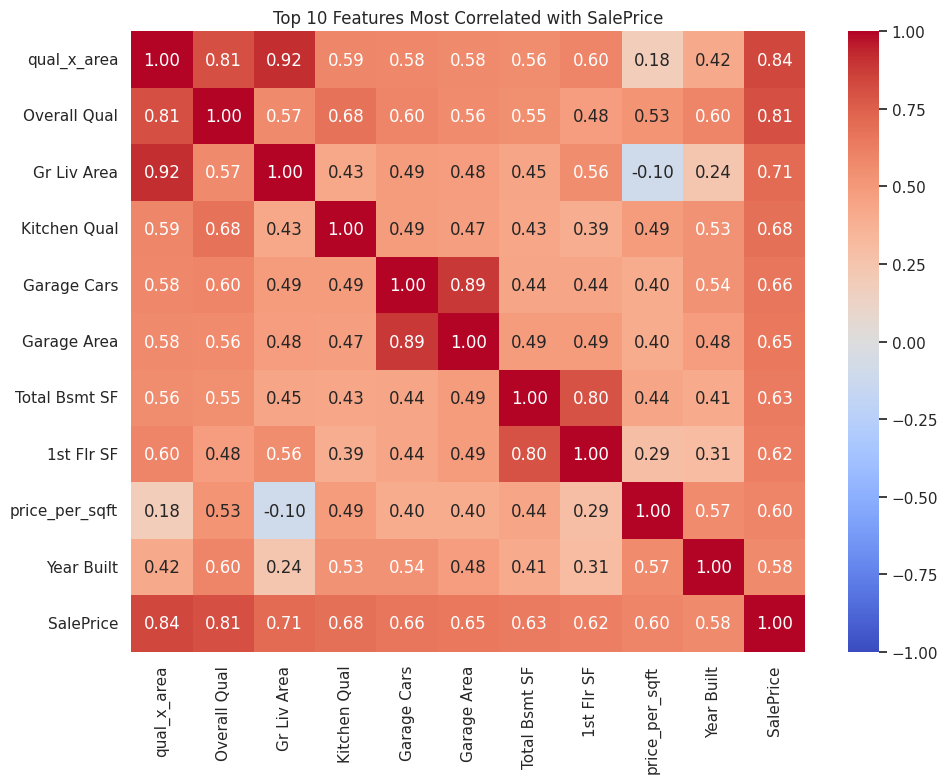

Top 10 correlations with SalePrice:
qual_x_area       0.84
Overall Qual      0.81
Gr Liv Area       0.71
Kitchen Qual      0.68
Garage Cars       0.66
Garage Area       0.65
Total Bsmt SF     0.63
1st Flr SF        0.62
price_per_sqft    0.60
Year Built        0.58
Name: SalePrice, dtype: float64


In [4]:
# Source: Week 7, Day 33 — Heatmaps and Correlation Matrices
numeric_df = df.select_dtypes(include=[np.number])
corr_with_target = numeric_df.corr()['SalePrice'].abs().sort_values(ascending=False)
top10_cols = corr_with_target.iloc[1:11].index.tolist()  # exclude SalePrice itself

top10_corr = numeric_df[top10_cols + ['SalePrice']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(top10_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Top 10 Features Most Correlated with SalePrice')
plt.tight_layout()
plt.show()

print('Top 10 correlations with SalePrice:')
print(corr_with_target.iloc[1:11].round(2))

# **Task 4: Scatter Plot**

---
# **We plot a key relationship with colour or size for a third variable**

---
**Insight:** qual_x_area has the strongest correlation with SalePrice (0.84),
confirming that our engineered interaction feature captures more signal than
either quality or area alone. Garage Cars and Garage Area are highly correlated
with each other (0.89), suggesting one could be dropped.


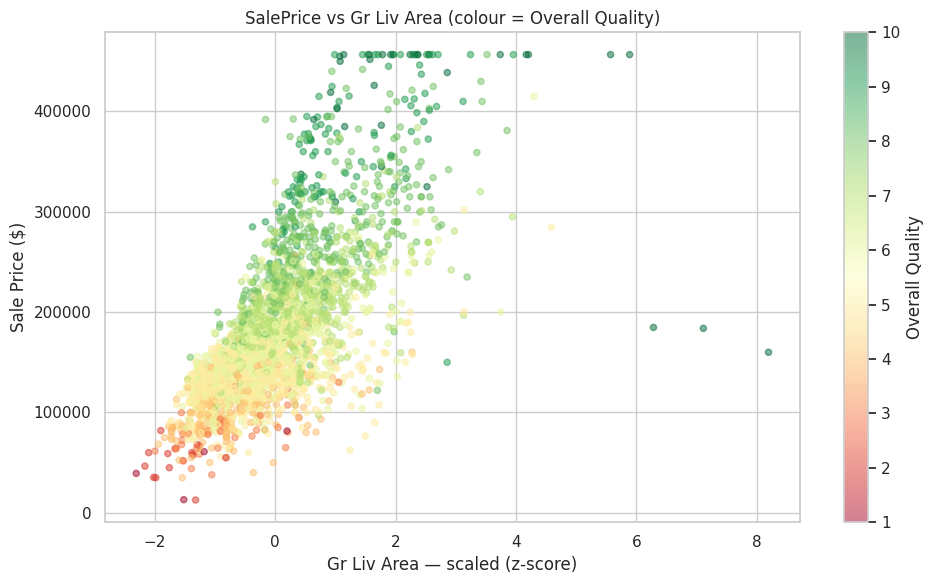

In [5]:
# Source: Week 7, Day 32 — Relationship Plots & scatterplot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['Gr Liv Area'],df['SalePrice'],
    c=df['Overall Qual'], cmap='RdYlGn',
    alpha=0.5, s=20
)
plt.colorbar(scatter, label='Overall Quality')
plt.title('SalePrice vs Gr Liv Area (colour = Overall Quality)')
plt.xlabel('Gr Liv Area — scaled (z-score)')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

# **Task 5: Groupby Summary**

---
# **ompute mean target by a category**

---
**Insight:** New houses average $283k versus $129k for Very Old houses —
a 2.2x difference. This confirms that House Age Group is a meaningful
predictor of sale price and justifies the binning decision in Phase 2.


SalePrice by House Age Group:
                 Mean Price  Median Price  Count
House Age Group                                 
New                283116.0      267916.0      3
Recent             238730.0      218689.0   1113
Mid                160626.0      150000.0    484
Old                142085.0      137500.0    848
Very Old           129563.0      122250.0    481


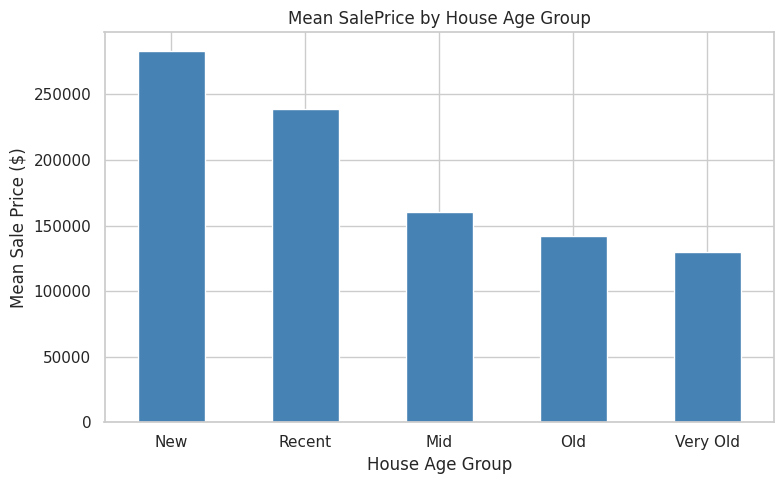

In [6]:
# Source: Week 6, Day 28 — Groupby & Aggregation
group_summary = (df.groupby('House Age Group')['SalePrice'].agg(['mean', 'median', 'count']).round(0).sort_values('mean', ascending=False))
group_summary.columns = ['Mean Price', 'Median Price', 'Count']
print('SalePrice by House Age Group:')
print(group_summary)
plt.figure(figsize=(8, 5))
group_summary['Mean Price'].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Mean SalePrice by House Age Group')
plt.xlabel('House Age Group')
plt.ylabel('Mean Sale Price ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()